**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC4029 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 6**
Ingeniería de características (FE)

---

*   NOMBRE:
    
    -José Florencio Maguey Peralta
    
    -Sebastian Almeida Cañez

    -Carlos Emilio Romero Polanco

    -Luis Daniel Castañeda Favela

*   MATRÍCULA:
    
    -A01796727
    
    -A01796440

    -A01632239

    -A00469356

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
DIR = "/content/drive/MyDrive/Colab Notebooks/Ciencia de datos/Modulo 6"
os.chdir(DIR)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [4]:
cars_df = pd.read_csv('vehicles.csv')
cars_df

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426875,7301591192,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,23590,2019.0,nissan,maxima s sedan 4d,good,6 cylinders,...,NaN,sedan,NaN,https://images.craigslist.org/00o0o_iiraFnHg8q...,Carvana is the safer way to buy a car During t...,NaN,wy,33.786500,-84.445400,2021-04-04T03:21:31-0600
426876,7301591187,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,30590,2020.0,volvo,s60 t5 momentum sedan 4d,good,NaN,...,NaN,sedan,red,https://images.craigslist.org/00x0x_15sbgnxCIS...,Carvana is the safer way to buy a car During t...,NaN,wy,33.786500,-84.445400,2021-04-04T03:21:29-0600
426877,7301591147,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,34990,2020.0,cadillac,xt4 sport suv 4d,good,NaN,...,NaN,hatchback,white,https://images.craigslist.org/00L0L_farM7bxnxR...,Carvana is the safer way to buy a car During t...,NaN,wy,33.779214,-84.411811,2021-04-04T03:21:17-0600
426878,7301591140,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,28990,2018.0,lexus,es 350 sedan 4d,good,6 cylinders,...,NaN,sedan,silver,https://images.craigslist.org/00z0z_bKnIVGLkDT...,Carvana is the safer way to buy a car During t...,NaN,wy,33.786500,-84.445400,2021-04-04T03:21:11-0600


# **Parte 1**. Preprocesamiento

1a)    Elimina las columnas que no serán relevantes para esta actividad: `id`, `VIN`, `url`, `image_url`, `description`, `posting_date`, `lat`, `long`.


In [5]:
cars_df.drop(['id', 'VIN', 'url', 'image_url', 'description', 'posting_date', 'lat', 'long'], axis=1, inplace=True)
cars_df

,region,region_url,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,paint_color,county,state
0,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426875,wyoming,https://wyoming.craigslist.org,23590,2019.0,nissan,maxima s sedan 4d,good,6 cylinders,gas,32226.0,clean,other,fwd,NaN,sedan,NaN,NaN,wy
426876,wyoming,https://wyoming.craigslist.org,30590,2020.0,volvo,s60 t5 momentum sedan 4d,good,NaN,gas,12029.0,clean,other,fwd,NaN,sedan,red,NaN,wy
426877,wyoming,https://wyoming.craigslist.org,34990,2020.0,cadillac,xt4 sport suv 4d,good,NaN,diesel,4174.0,clean,other,NaN,NaN,hatchback,white,NaN,wy
426878,wyoming,https://wyoming.craigslist.org,28990,2018.0,lexus,es 350 sedan 4d,good,6 cylinders,gas,30112.0,clean,other,fwd,NaN,sedan,silver,NaN,wy


1b) Almacena en una variable la cantidad de observaciones o registros del dataframe y en otra el número de columnas (después del borrado) para análisis posteriores.

In [6]:
rcars=cars_df.shape[0]
rcars

426880

In [7]:
ccars=cars_df.shape[1]
ccars

18

## Valores faltantes

Cuando la cantidad de valores faltantes en una columna es lo suficientemente grande (aproximadamente más del 25%), estimar e ingresar los valores faltantes no tiene sentido, y eliminar el atributo es mejor que estimar los valores faltantes. https://learning.oreilly.com/library/view/hands-on-data-preprocessing/9781801072137/B17397_11_Final_NM_ePub.xhtml#_idParaDest-188

Sin embargo, esto no es una regla aplicable a todos los escenarios y hay muchas discusiones en torno a ello. https://www.quora.com/How-much-missing-data-is-too-much-1

Para esta actividad  utilizaremos un umbral de 0.70 de la cantidad de registros (aquellas columnas que tengan 70% de valores no nulos). Considera además que estamos asumiendo que dichas variables son MCAR o MAR sin ninguna método gráfico o estadístico.

2a) Determina el porcentaje de valores faltantes por columna y elimina aquellas que posean el 30% o más de valores perdidos. Para ello utiliza el parámetro `thresh` de la función `dropna()` ¿Cuántas columnas se eliminaron?


In [8]:
for i in cars_df.columns:
  print('{}|{}|{}%'.format(i, cars_df[i].isna().sum(),(cars_df[i].isna().sum()/rcars)*100))

region|0|0.0%
region_url|0|0.0%
price|0|0.0%
year|1205|0.28228073463268366%
manufacturer|17646|4.133714392803598%
model|5277|1.2361787856071964%
condition|174104|40.78523238380809%
cylinders|177678|41.6224700149925%
fuel|3013|0.7058189655172414%
odometer|4400|1.0307346326836582%
title_status|8242|1.9307533733133435%
transmission|2556|0.5987631184407797%
drive|130567|30.586347451274364%
size|306361|71.7674756371814%
type|92858|21.752717391304348%
paint_color|130203|30.501077586206897%
county|426880|100.0%
state|0|0.0%


In [9]:
cars_df.dropna(thresh=rcars*0.7, axis=1, inplace=True)
cars_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   region        426880 non-null  object 
 1   region_url    426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   fuel          423867 non-null  object 
 7   odometer      422480 non-null  float64
 8   title_status  418638 non-null  object 
 9   transmission  424324 non-null  object 
 10  type          334022 non-null  object 
 11  state         426880 non-null  object 
dtypes: float64(2), int64(1), object(9)
memory usage: 39.1+ MB


In [10]:
cars_df.shape

(426880, 12)

Además, cuando tenemos grandes conjuntos de datos, podemos eliminar filas que contienen valores nulos. Aunque, no se recomienda si el porcentaje de valores faltantes en el conjunto de datos es superior al 30%
https://medium.com/analytics-vidhya/how-to-deal-with-missing-values-in-data-set-8e8f70ecf155

2b) Borra los registros que contengan `NaN` en las columnas con menos del 5% de valores faltantes empleando el parámetro subset ¿Qué porcentaje de los registros iniciales se eliminaron?


In [11]:
for i in cars_df.columns:
  print('{}|{}|{}'.format(i, cars_df[i].isna().sum(),(cars_df[i].isna().sum()/rcars)*100))

region|0|0.0
region_url|0|0.0
price|0|0.0
year|1205|0.28228073463268366
manufacturer|17646|4.133714392803598
model|5277|1.2361787856071964
fuel|3013|0.7058189655172414
odometer|4400|1.0307346326836582
title_status|8242|1.9307533733133435
transmission|2556|0.5987631184407797
type|92858|21.752717391304348
state|0|0.0


In [12]:
reg05=rcars*0.05
reg05
bm_Mcol=cars_df.isnull().sum()<=reg05
cols=cars_df.columns[bm_Mcol]
cars_df.dropna(subset=cols, inplace=True)
#cars_df

In [13]:
#% eliminado
print('{}%'.format((rcars-cars_df.shape[0])/rcars*100))

8.7321964017991%


2c) Si hay variables que aún poseen valores faltantes, utiliza el método de imputación apropiado (`mean, median, mode`)

In [14]:
cars_df.isna().sum()

,0
region,0
region_url,0
price,0
year,0
manufacturer,0
model,0
fuel,0
odometer,0
title_status,0
transmission,0


In [15]:
for col in cars_df.columns:
  if cars_df[col].dtype != 'object':
    print(col, cars_df[col].skew(numeric_only=True))

price 283.57343890830685
year -3.490463560669928
odometer 41.65017281060572


In [16]:
from sklearn.impute import SimpleImputer

for col in cars_df[['year','price','odometer']]:
  if cars_df[col].dtype == 'object':
    imputer = SimpleImputer(strategy='most_frequent')
  else:
    imputer = SimpleImputer(strategy='median')

  cars_df[col] = imputer.fit_transform(cars_df[[col]])



In [17]:
cars_df.isna().sum()

,0
region,0
region_url,0
price,0
year,0
manufacturer,0
model,0
fuel,0
odometer,0
title_status,0
transmission,0


## Valores atípicos

3a) Obtén el histograma de las variables `price`, `year` y `odometer` para observar su distribución.

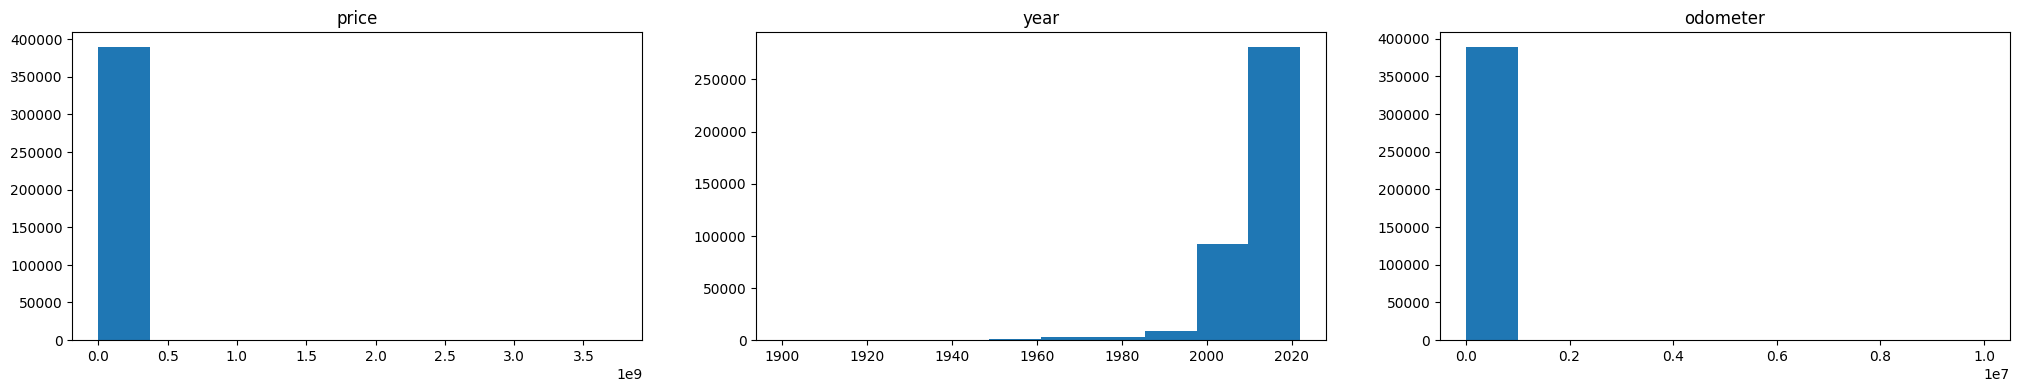

In [18]:
fig, axes = plt.subplots(1,3, figsize=(25,4))
axes = axes.ravel()
for col, ax in zip(cars_df[['price', 'year', 'odometer']], axes):
  ax.hist(cars_df[col])
  ax.set(title=f'{col}', xlabel=None)

3b) Añade la columna `age`, calculada a partir de `year`, para determinar los años del vehículo y una vez obtenida, elimina la columna `year`. Genera el histograma de la nueva variable.

In [19]:
cars_df['age']=2024-cars_df['year']
cars_df.drop('year', axis=1, inplace=True)
cars_df

,region,region_url,price,manufacturer,model,fuel,odometer,title_status,transmission,type,state,age
27,auburn,https://auburn.craigslist.org,33590.0,gmc,sierra 1500 crew cab slt,gas,57923.0,clean,other,pickup,al,10.0
28,auburn,https://auburn.craigslist.org,22590.0,chevrolet,silverado 1500,gas,71229.0,clean,other,pickup,al,14.0
29,auburn,https://auburn.craigslist.org,39590.0,chevrolet,silverado 1500 crew,gas,19160.0,clean,other,pickup,al,4.0
30,auburn,https://auburn.craigslist.org,30990.0,toyota,tundra double cab sr,gas,41124.0,clean,other,pickup,al,7.0
31,auburn,https://auburn.craigslist.org,15000.0,ford,f-150 xlt,gas,128000.0,clean,automatic,truck,al,11.0
...,...,...,...,...,...,...,...,...,...,...,...,...
426875,wyoming,https://wyoming.craigslist.org,23590.0,nissan,maxima s sedan 4d,gas,32226.0,clean,other,sedan,wy,5.0
426876,wyoming,https://wyoming.craigslist.org,30590.0,volvo,s60 t5 momentum sedan 4d,gas,12029.0,clean,other,sedan,wy,4.0
426877,wyoming,https://wyoming.craigslist.org,34990.0,cadillac,xt4 sport suv 4d,diesel,4174.0,clean,other,hatchback,wy,4.0
426878,wyoming,https://wyoming.craigslist.org,28990.0,lexus,es 350 sedan 4d,gas,30112.0,clean,other,sedan,wy,6.0


4a) Para visualizar si hay valores atípicos, genera gráficos de box plot para las tres variables (`price, age, odometer`)

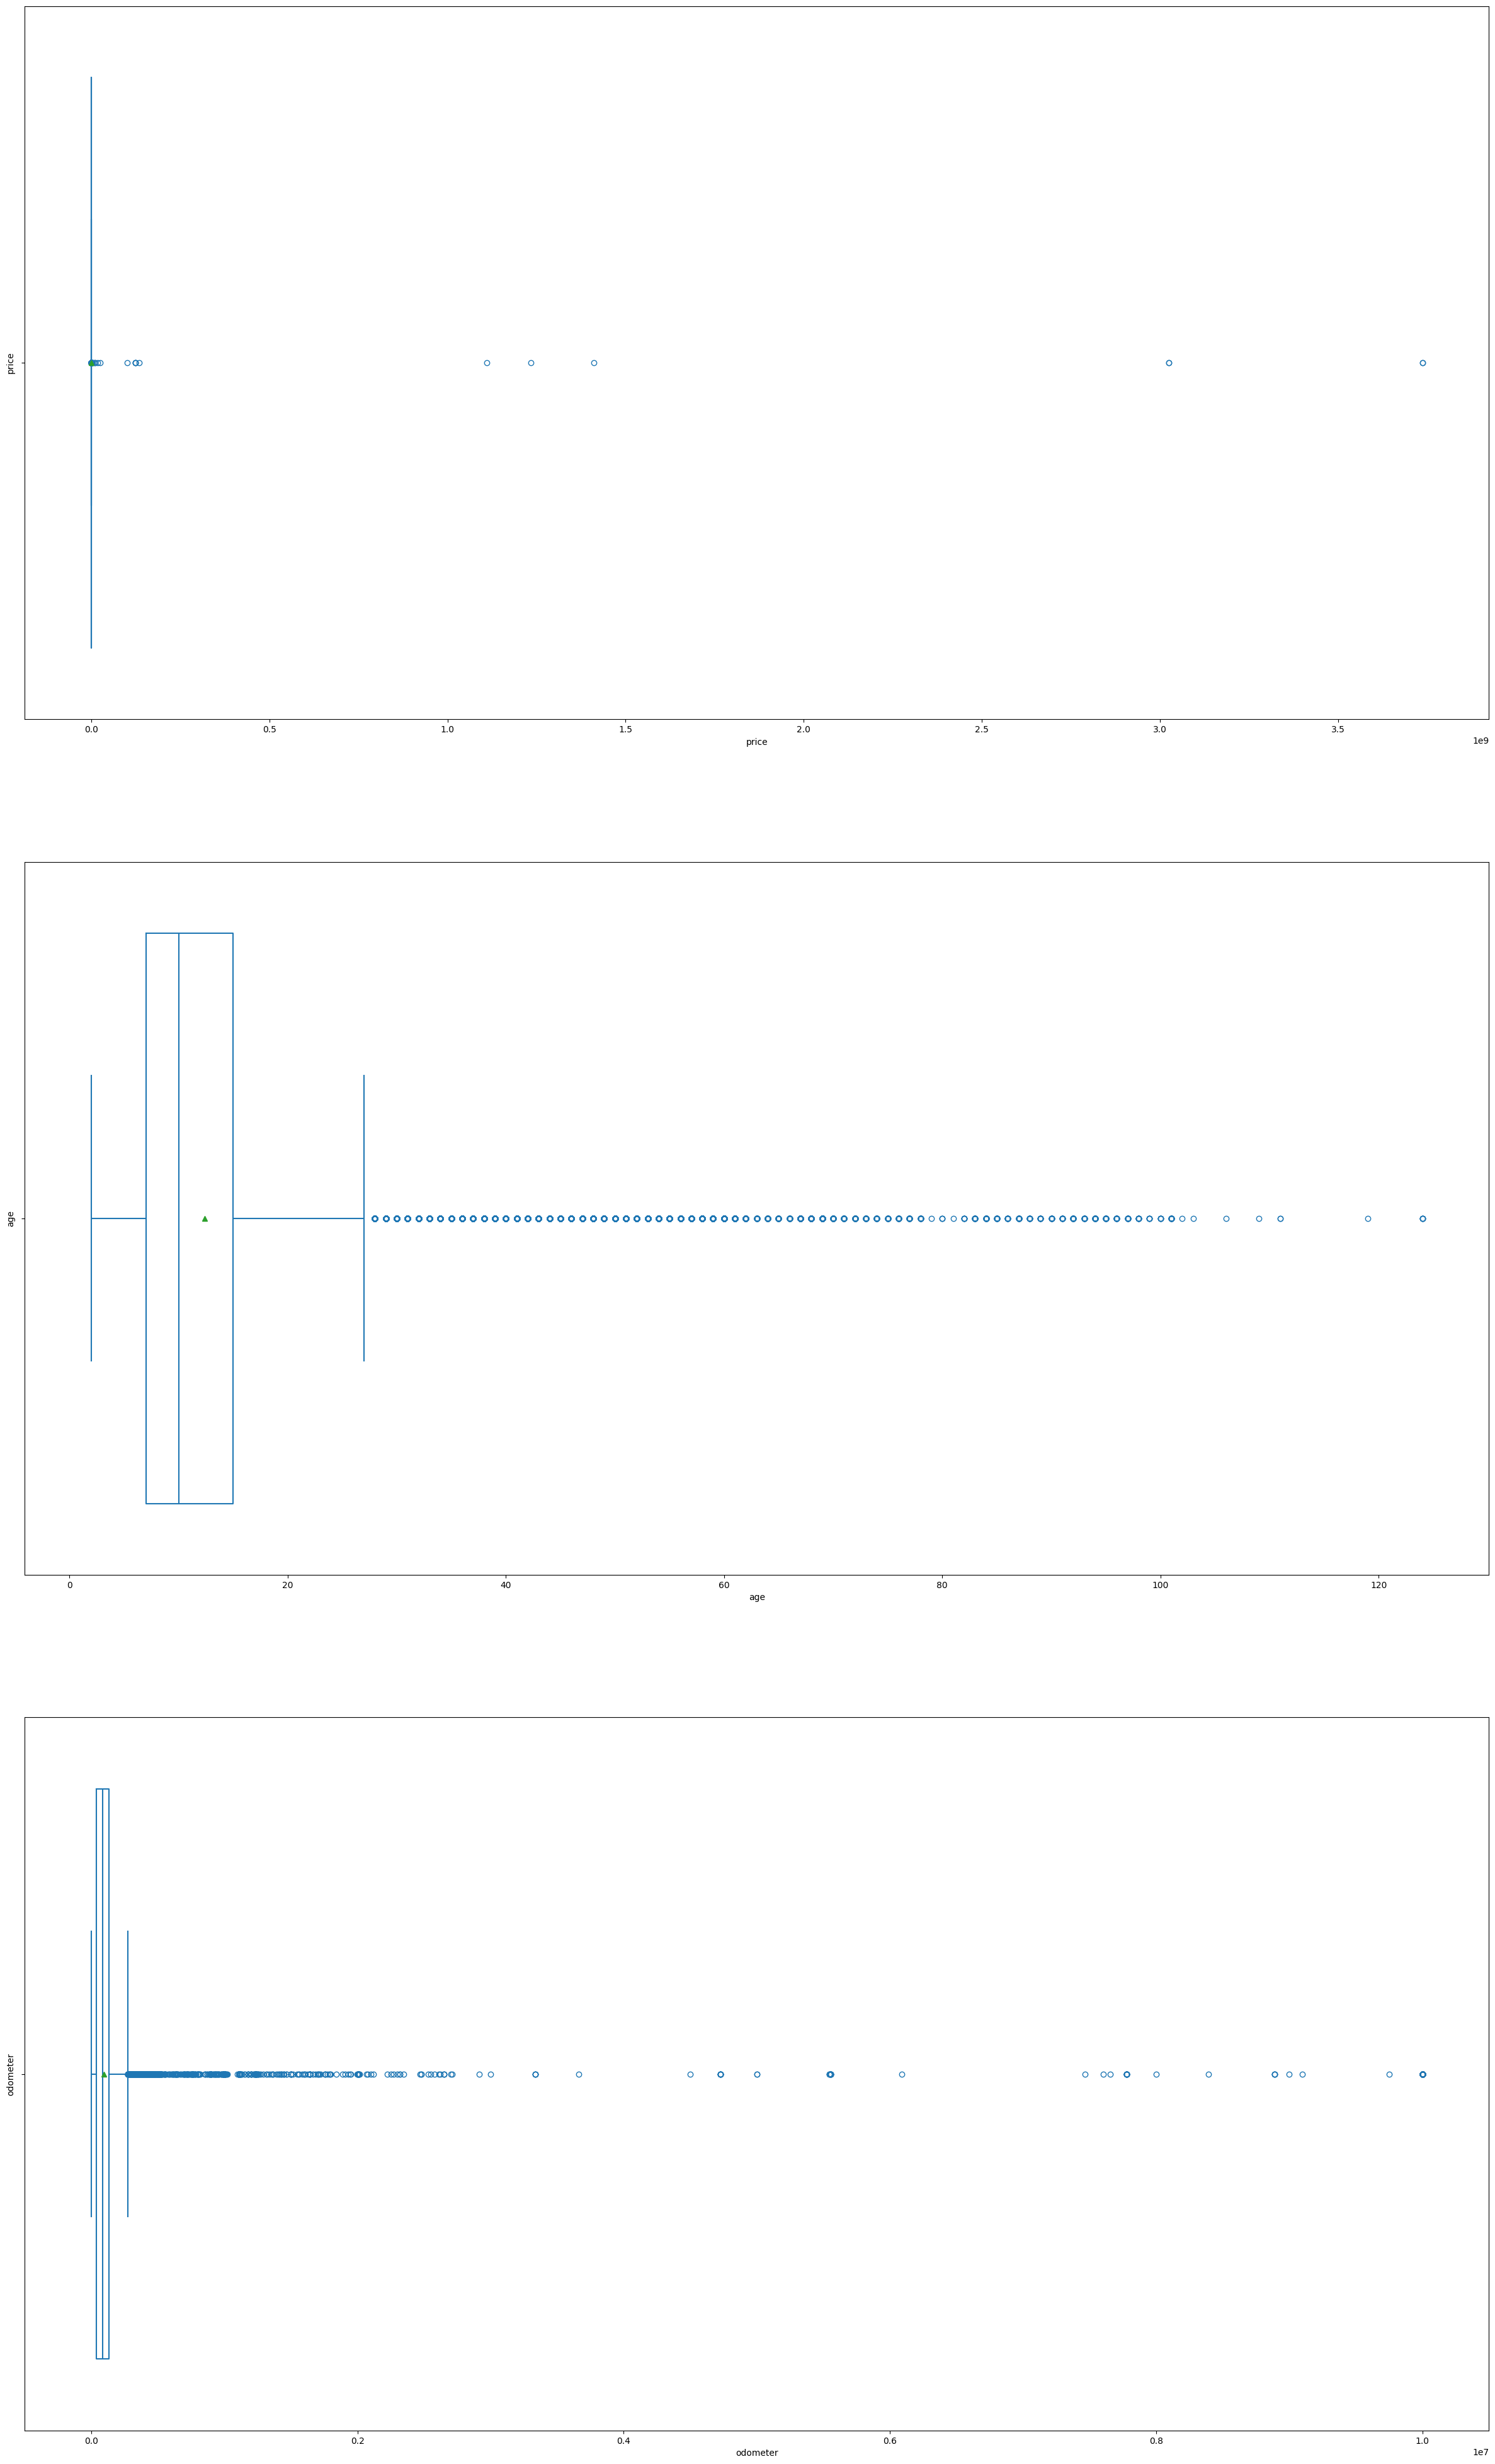

In [20]:
fig, axes = plt.subplots(3,1, figsize=(30,50))
axes = axes.ravel()

for col, ax in zip(cars_df[['price', 'age', 'odometer']], axes):
    sns.boxplot(data=cars_df, x=col, ax=ax, showmeans=True, fill=False)
    ax.set(ylabel=f'{col}')

Si el conjunto de outliers es “relativamente grande” (aunque sabemos que deben andar alrededor de un 5% del conjunto total de datos), realizar una investigación particular sobre ellos que permita tomar mejores decisiones.

4b) Calcula, para cada variable, el porcentaje de sus valores atípicos y elimínalos del dataframe ¿Qué porcentaje de los registros iniciales se han eliminado en total hasta ahora?

In [21]:
#hacer el IQR
for col in cars_df[['price','age', 'odometer']]:
  ucap= cars_df[col].quantile(0.75) + (1.5*(cars_df[col].quantile(0.75)-cars_df[col].quantile(0.25)))
  lcap= cars_df[col].quantile(0.25) - (1.5*(cars_df[col].quantile(0.75)-cars_df[col].quantile(0.25)))
  BM_lcap=cars_df[col]<lcap
  BM_ucap=cars_df[col]>ucap
  cars_df = cars_df[~BM_lcap & ~BM_ucap]

print('{}%'.format((rcars-cars_df.shape[0])/rcars*100))

13.69166979010495%


4c) Dibuja nuevamente los histogramas para observar claramente el sesgo de las variables tras la eliminación de los outliers.

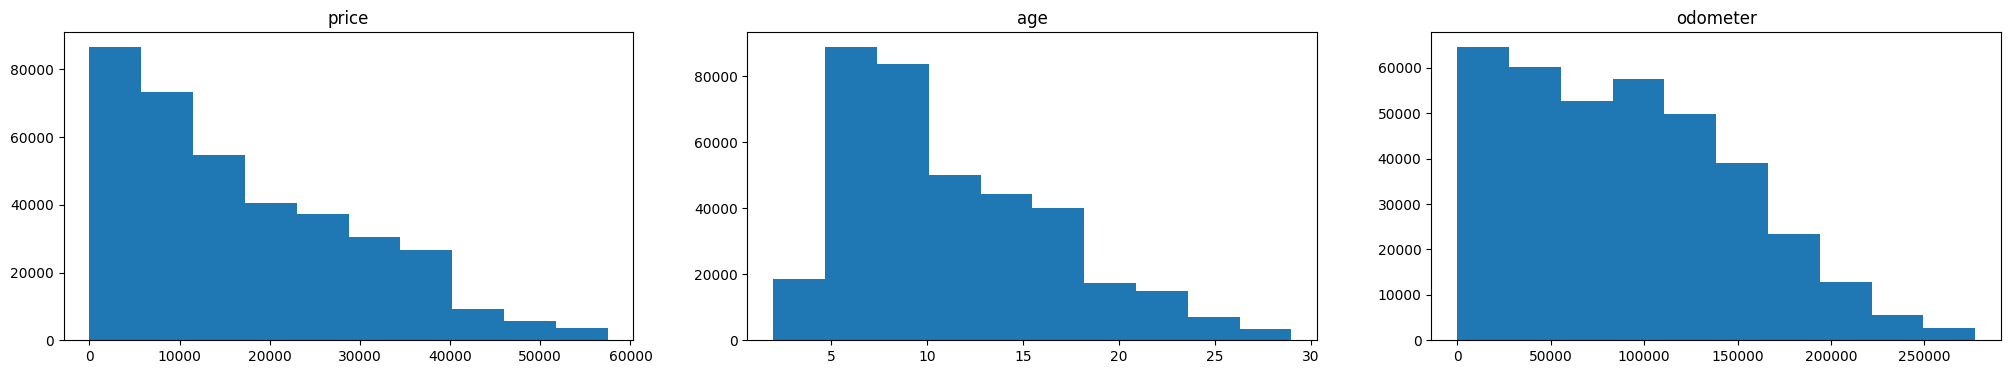

In [22]:
fig, axes = plt.subplots(1,3, figsize=(25,4))
axes = axes.ravel()
for col, ax in zip(cars_df[['price', 'age', 'odometer']], axes):
  ax.hist(cars_df[col])
  ax.set(title=f'{col}', xlabel=None)

# **Parte 2**. Ingeniería de características

## Transformando variables numéricas

La distribución de las variables determinará que método usar y en qué orden. Por ejemplo, en variables sesgadas se debe realizar primero la transformación  y luego el escalamiento, ya que el efecto deseado es "desinclinar" las distribuciones del eje y ese efecto se maximiza cuando aplica en el rango completo en comparación con aplicarlo en variables con una desviación estándar unitaria (por z-score) o variables en el rango [0,1] (por Min-Max).

Aplicar es escalamiento antes comprimiría la mayoría de los datos en un rango estrecho. Entonces se debe iniciar con transformar la característica en Gaussiana y luego escalarla.

5a) Genera gráficos Q-Q de las variables `price, age, odometer` para observar las diferencias entre sus distribuciones y la normal.


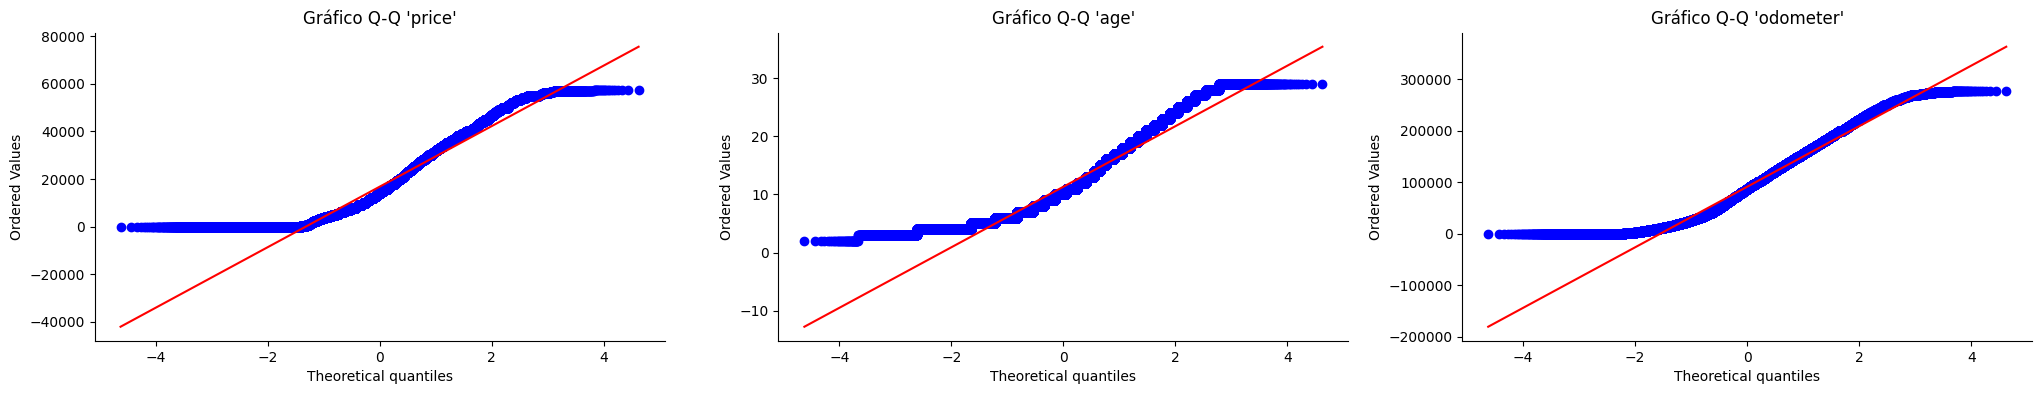

In [23]:
fig, axes = plt.subplots(1,3, figsize=(25,4))
axes = axes.ravel()
for col, ax in zip(cars_df[['price', 'age', 'odometer']], axes):
  stats.probplot(cars_df[col], dist="norm", plot=ax)
  sns.despine(ax=ax)
  ax.set_title(f"Gráfico Q-Q '{col}'")

Las transformaciones *Box-Cox* y *Yeo-Johnson* son generalizaciones, pues incluyen casos especiales de transformaciones: logarítmica (`λ = 0`), recíproca (`λ = -1`),  raíz cuadrada (`λ = 0.5`) y más exponentes. En *Box-Cox* se evalúan varios valores de `λ` y se selecciona aquel que arroja la mejor transformación

La transformación de *Yeo-Johnson* es una extensión de la transformación de *Box-Cox* que ya no está restringida a valores positivos. En otras palabras, la transformación de *Yeo-Johnson* se puede utilizar en variables con valores cero y negativos, así como valores positivos. Cuando la variable solo tiene valores positivos, la transformación de *Yeo-Johnson* es como la transformación de *Box-Cox* de la variable más uno.

En este caso, como las variables `price` y `odometer` tienen valores de 0, utilizaremos *Yeo-Johnson*.

Recuerda que en `PowerTransformer()` el parámetro `standardize` por defecto es `True`. Con esto, después de hacer la transformación, el resultado se escala con *Z-score*, haciendo que la media sea 0 y la desviación estándar 1. Como en el ejercicio 6 ocuparás Min-Max para escalar, haz `standardize=False` para omitir el escalamiento en esta fase.

5b) Aplica la transformación Yeo-Johnson para reducir el sesgo en estas variables. Coloca el resultado en un dataframe denominado `transf_df` que contenga sólo las variables transformadas.

In [24]:
from sklearn.preprocessing import PowerTransformer

In [25]:
trans_df=cars_df[['price', 'age', 'odometer']]
transformer = PowerTransformer(method='yeo-johnson',standardize=False)
trans_df=transformer.fit_transform(trans_df)
trans_df=pd.DataFrame(trans_df, columns=['price', 'age', 'odometer'])
trans_df

,price,age,odometer
0,193.563980,2.387911,625.632001
1,163.225489,2.695321,698.226485
2,207.706309,1.604936,347.483442
3,186.983245,2.071931,521.567174
4,136.831542,2.474186,952.940342
...,...,...,...
368428,166.295214,1.786181,458.182655
368429,185.942956,1.604936,271.179380
368430,196.986291,1.604936,154.051753
368431,181.701485,1.939332,441.951156


5c) Dibuja nuevamente los gráficos Q-Q y los histogramas para observar el efecto de la transformación.

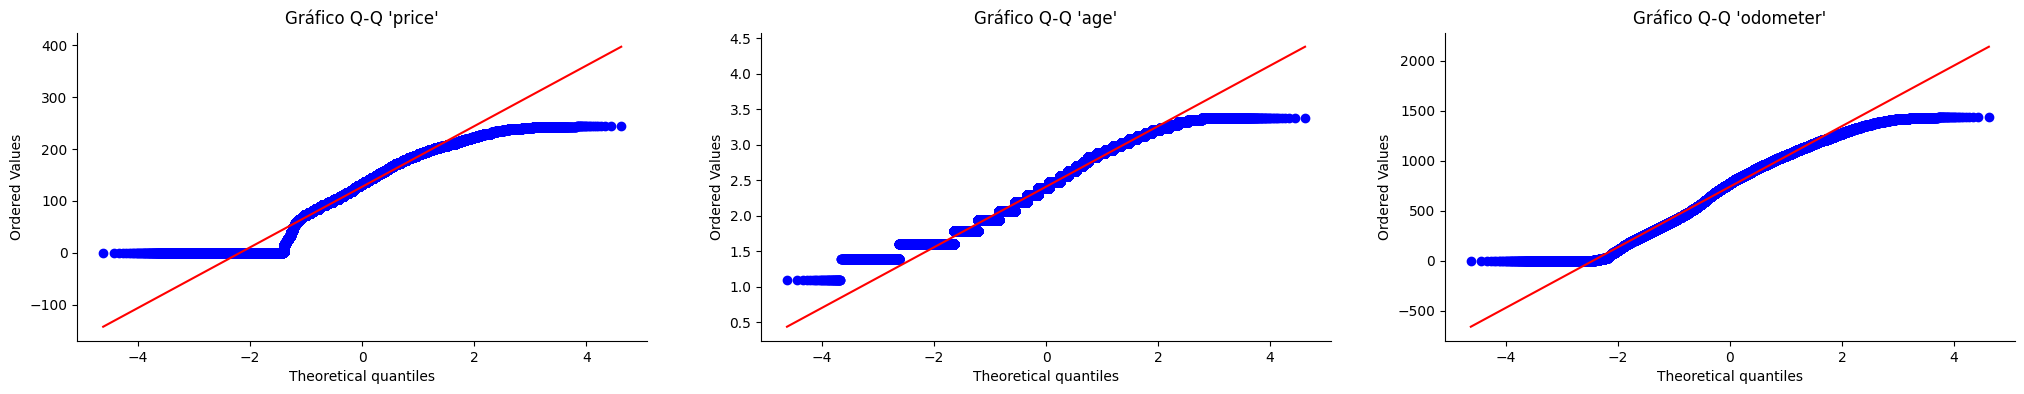

In [26]:
fig, axes = plt.subplots(1,3, figsize=(25,4))
axes = axes.ravel()
for col, ax in zip(trans_df, axes):
  stats.probplot(trans_df[col], dist="norm", plot=ax)
  sns.despine(ax=ax)
  ax.set_title(f"Gráfico Q-Q '{col}'")

## Escalando variables numéricas

6a) Como las tres variables poseen diferentes escalas, aplica el método Min-Max (al dataframe obtenido: `transf_df`) para que queden en el rango fijo [0 a 1]. Coloca el resultado en un dataframe denominado `minmax_df`.


In [27]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
minmax_df = scaler.fit_transform(trans_df)
minmax_df = pd.DataFrame(minmax_df, columns=['price', 'age', 'odometer'])
minmax_df

,price,age,odometer
0,0.794413,0.565257,0.435888
1,0.669900,0.699813,0.486465
2,0.852455,0.222541,0.242097
3,0.767405,0.426949,0.363384
4,0.561575,0.603020,0.663928
...,...,...,...
368428,0.682498,0.301874,0.319223
368429,0.763135,0.222541,0.188935
368430,0.808459,0.222541,0.107330
368431,0.745728,0.368910,0.307914


6b) Dibuja nuevamente los histogramas para verificar que el escalamiento no cambia la distribución.

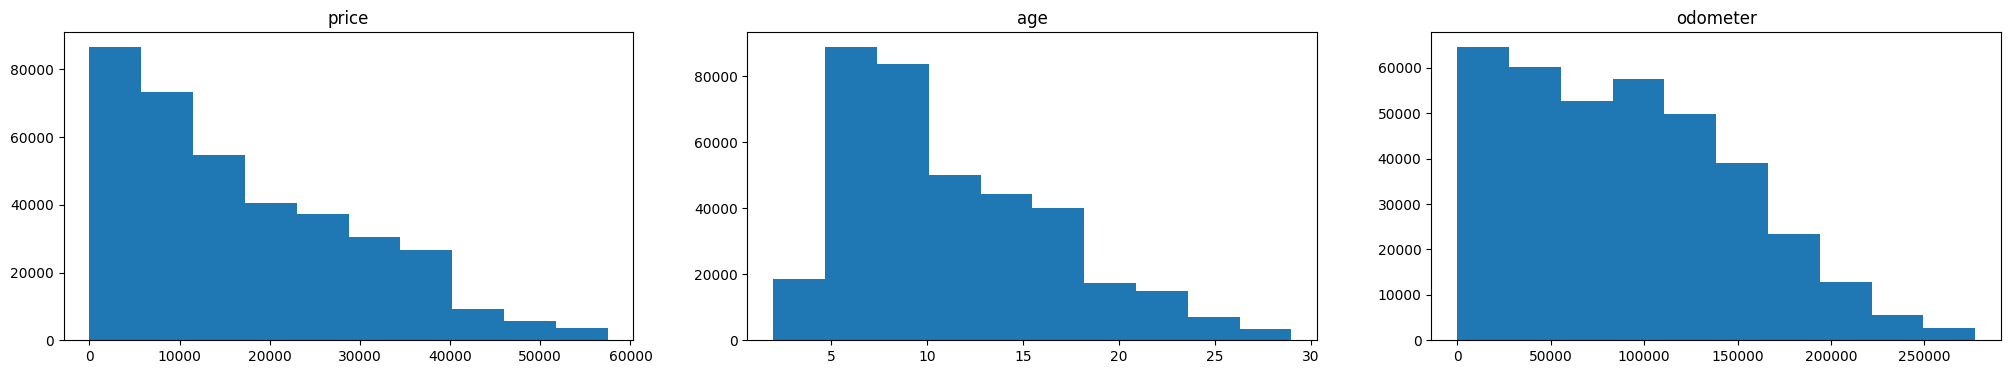

In [28]:
fig, axes = plt.subplots(1,3, figsize=(25,4))
axes = axes.ravel()
for col, ax in zip(minmax_df, axes):
  ax.hist(cars_df[col])
  ax.set(title=f'{col}', xlabel=None)

## Codificando variables categóricas


7a) Utiliza el método `describe()` para obtener el resumen de las estadísticas descriptivas en las variables categóricas.

In [29]:
cars_df.describe(include = 'object').T

,count,unique,top,freq
region,368433,404,columbus,3201
region_url,368433,413,https://grandrapids.craigslist.org,2745
manufacturer,368433,40,ford,62162
model,368433,19314,f-150,7477
fuel,368433,5,gas,313944
title_status,368433,6,clean,356757
transmission,368433,3,automatic,293338
type,292810,13,sedan,79583
state,368433,51,ca,42333


7b) Según la cardinalidad observada, separa en dos listas (`highly_cardinal_variables` y `few_cardinal_variables`) los nombres de las variables con alta cardinalidad y baja cardinalidad respectivamente. Una variable es considerada de alta cardinalidad cuando tiene cientos de valores únicos.

In [30]:
cat_cols = cars_df.select_dtypes(exclude=np.number).columns.tolist()

hvc_df =[]
fvc_df =[]

for col in cars_df[cat_cols]:
  if cars_df[col].nunique() > 100:
    hvc_df.append(col)
  else:
    fvc_df.append(col)

print("High Value Columns Description:")
print(hvc_df)

print("\nFew Value Columns Description:")
print(fvc_df)

High Value Columns Description:
['region', 'region_url', 'model']

Few Value Columns Description:
['manufacturer', 'fuel', 'title_status', 'transmission', 'type', 'state']


7c) Visualiza en gráficos de barras la frecuencias de las categorías para las variables con baja cardinalidad (en `few_cardinal_variables`)

<ipython-input-31-7c4f57896a8f>:7: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
<ipython-input-31-7c4f57896a8f>:7: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
<ipython-input-31-7c4f57896a8f>:7: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
<ipython-input-31-7c4f57896a8f>:7: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
<ipython-input-31-7c4f57896a8f>:7: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
<ipython-input-31-7c4f57896a8f>:7: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


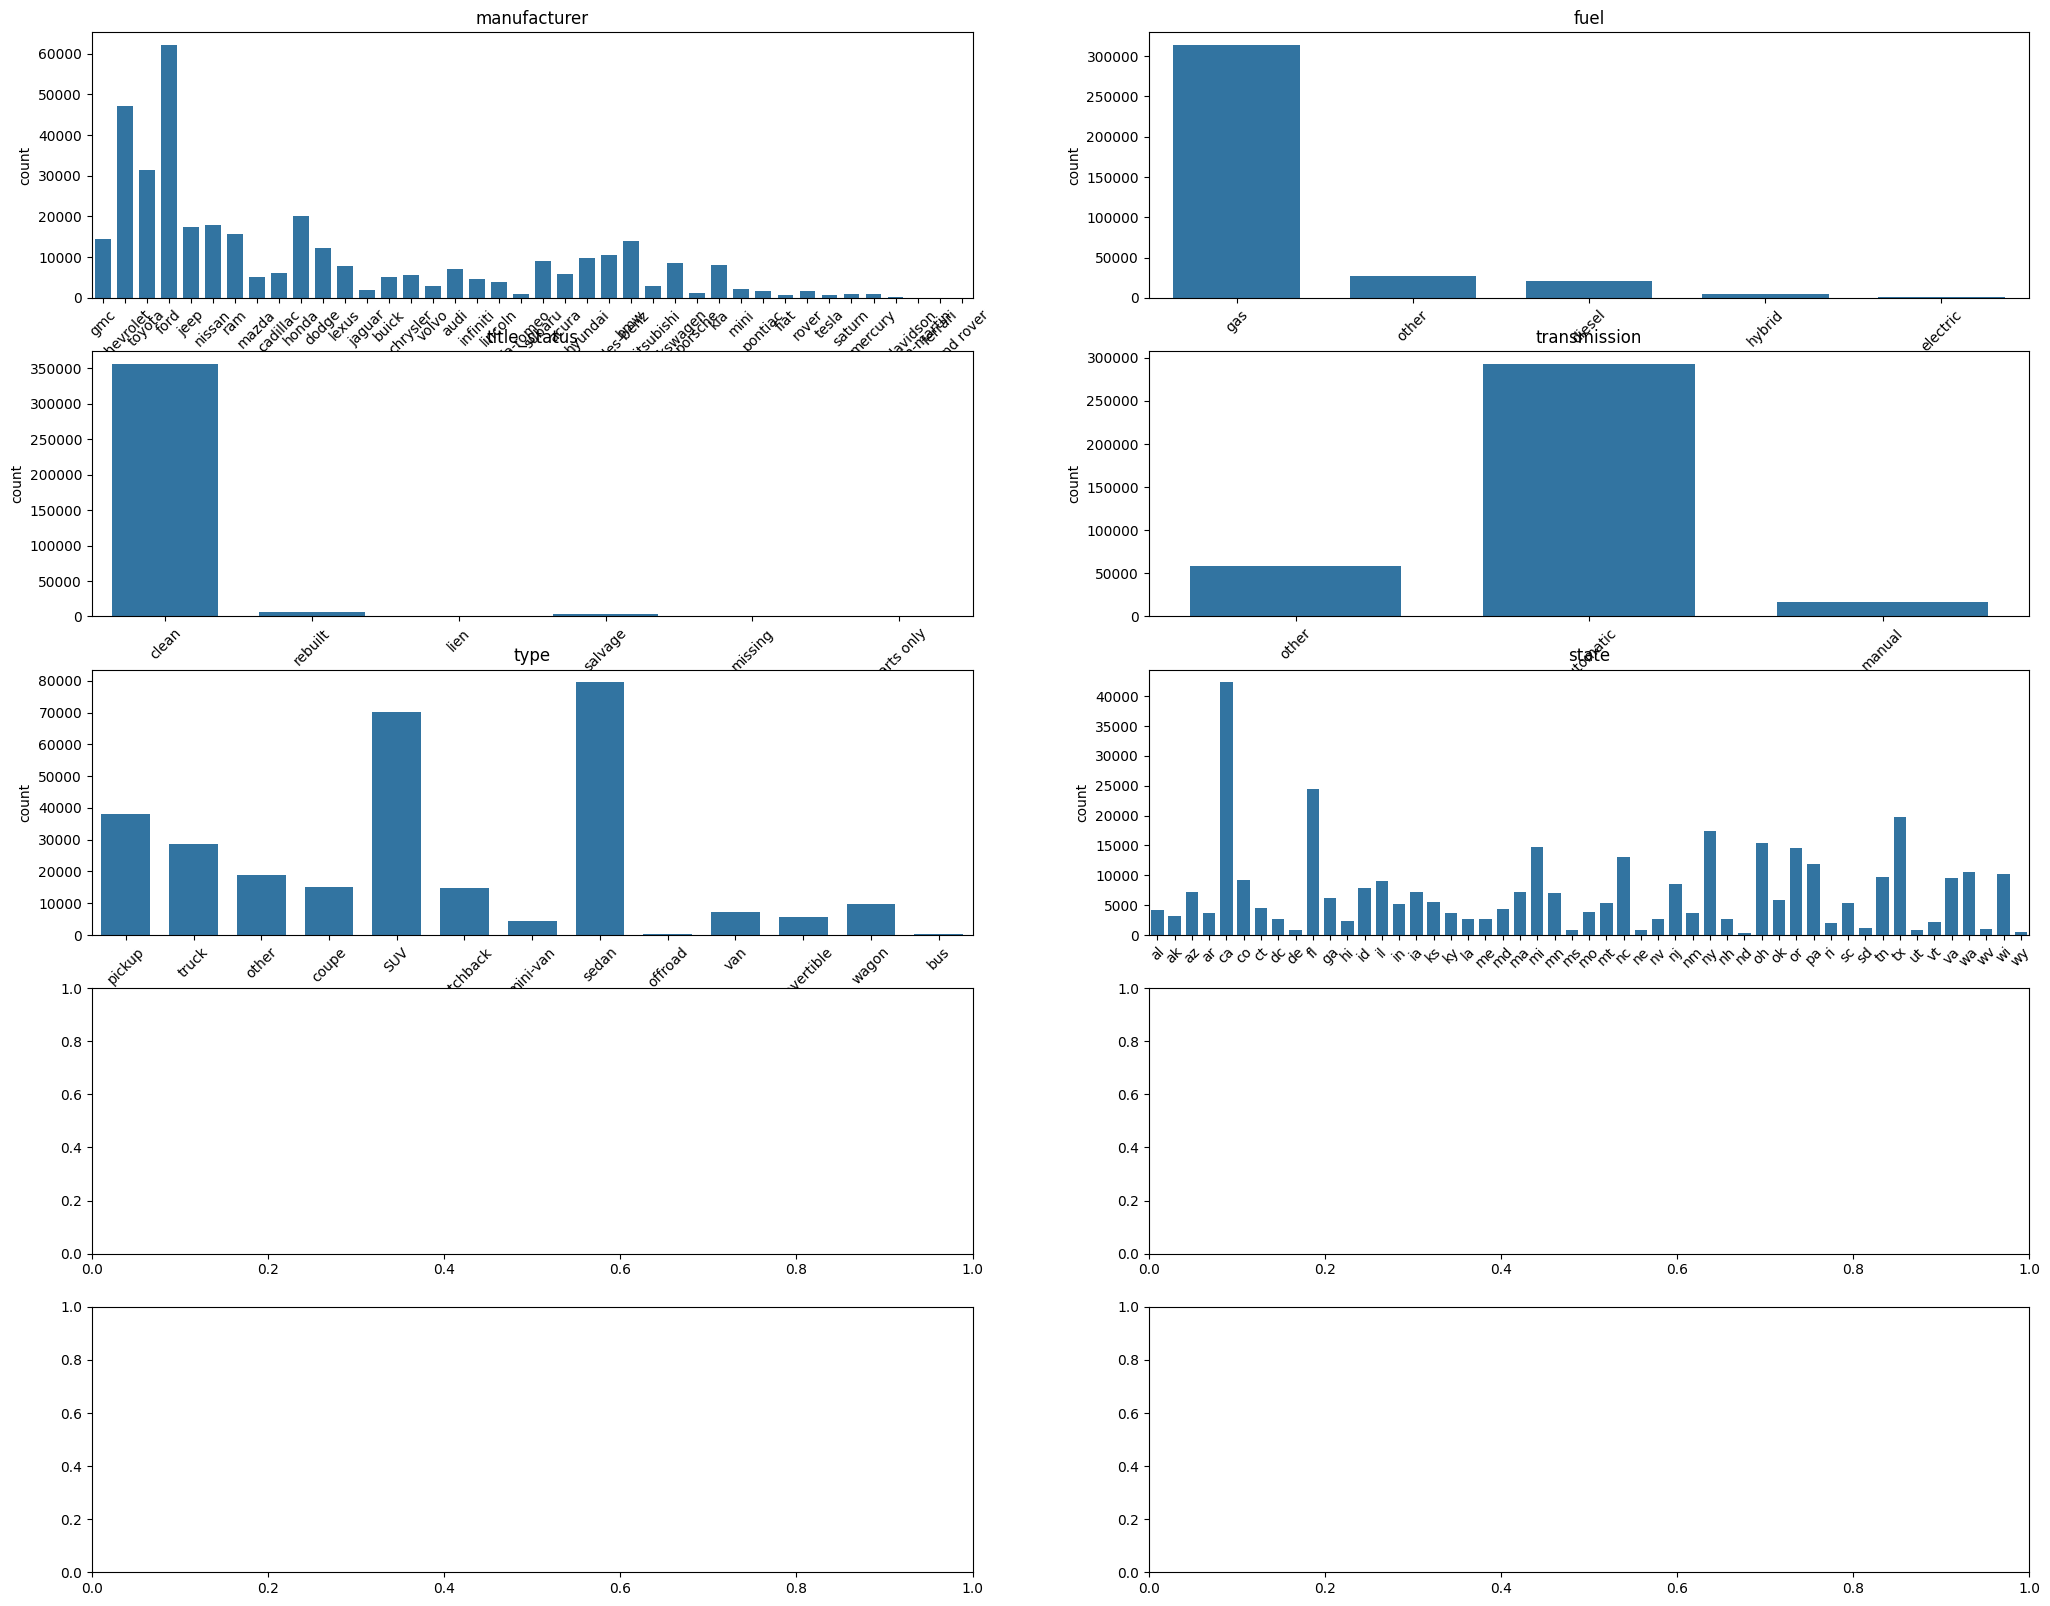

In [31]:
fig, axes = plt.subplots(5,2, figsize=(25,20))
axes = axes.ravel()
for col, ax in zip(fvc_df, axes):
  sns.countplot(data=cars_df, x=col, ax=ax, gap=0.1)
  ax.set(title=f'{col}', xlabel=None)
  ax.get_xticklabels()
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


8. Aplica codificación *one-hot* a las variables en `few_cardinal_variables`, borrando la primera categoría (`drop='first'`). Coloca el resultado en un dataframe denominado `onehot_df`.

In [32]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(drop='first', sparse_output=False)
encoded = encoder.fit_transform(cars_df[fvc_df])
onehot_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out())
onehot_df

,manufacturer_alfa-romeo,manufacturer_aston-martin,manufacturer_audi,manufacturer_bmw,manufacturer_buick,manufacturer_cadillac,manufacturer_chevrolet,manufacturer_chrysler,manufacturer_dodge,manufacturer_ferrari,...,state_sd,state_tn,state_tx,state_ut,state_va,state_vt,state_wa,state_wi,state_wv,state_wy
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
368428,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
368429,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
368430,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
368431,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


9. Aplica codificación binaria a las variables en `highly_cardinal_variables`. Coloca el resultado en un dataframe denominado `binary_df`.

In [33]:
!pip install category_encoders
from category_encoders.binary import BinaryEncoder
encoder = BinaryEncoder()
encoded_data = encoder.fit_transform(cars_df[hvc_df])
binary_df=pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out())
binary_df

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.0/82.0 kB 2.3 MB/s eta 0:00:00


,region_0,region_1,region_2,region_3,region_4,region_5,region_6,region_7,region_8,region_url_0,...,model_5,model_6,model_7,model_8,model_9,model_10,model_11,model_12,model_13,model_14
27,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
28,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0
29,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,1,1
30,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
31,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426875,1,1,0,0,1,0,1,0,0,1,...,1,1,0,0,1,0,1,1,0,1
426876,1,1,0,0,1,0,1,0,0,1,...,0,0,0,0,1,1,0,1,1,1
426877,1,1,0,0,1,0,1,0,0,1,...,0,0,0,0,0,1,1,0,1,1
426878,1,1,0,0,1,0,1,0,0,1,...,1,1,1,1,0,0,0,0,1,1


10. Concatena los dataframes obtenidos: `minmax_df` (cuyas variables numéricas ya están transformadas y escaladas) y las codificaciones anteriores (`onehot_df` y `binary_df`). Toma en cuenta que si los índices de los dataframes no coinciden, la concatenación no se realizará correctamente. Utiliza `reset_index(drop=True, inplace=True)` para restablecer los índices.

In [34]:
final_df = pd.concat([minmax_df, onehot_df, binary_df], axis=1)
final_df.reset_index(drop=True, inplace=True)
final_df

,price,age,odometer,manufacturer_alfa-romeo,manufacturer_aston-martin,manufacturer_audi,manufacturer_bmw,manufacturer_buick,manufacturer_cadillac,manufacturer_chevrolet,...,model_5,model_6,model_7,model_8,model_9,model_10,model_11,model_12,model_13,model_14
0,0.794413,0.565257,0.435888,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.669900,0.699813,0.486465,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.852455,0.222541,0.242097,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.767405,0.426949,0.363384,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.561575,0.603020,0.663928,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
418145,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0
418146,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
418147,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0
418148,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
